In [2]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os

In [4]:
os.getcwd()

'/Users/sara/Desktop/exercise/ham10000-classifier/notebooks'

In [6]:
df = pd.read_csv('../data/HAM10000_metadata.csv')
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [10]:
print("shape of the dataframe:", df.shape)
print("columns in the dataframe:", df.columns.tolist())

shape of the dataframe: (10015, 7)
columns in the dataframe: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


In [12]:
df['dx'].unique()

<StringArray>
['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
Length: 7, dtype: str

In [13]:
df['dx_type'].unique()

<StringArray>
['histo', 'consensus', 'confocal', 'follow_up']
Length: 4, dtype: str

In [14]:
df['lesion_id'].nunique()

7470

In [15]:
df['dx'].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

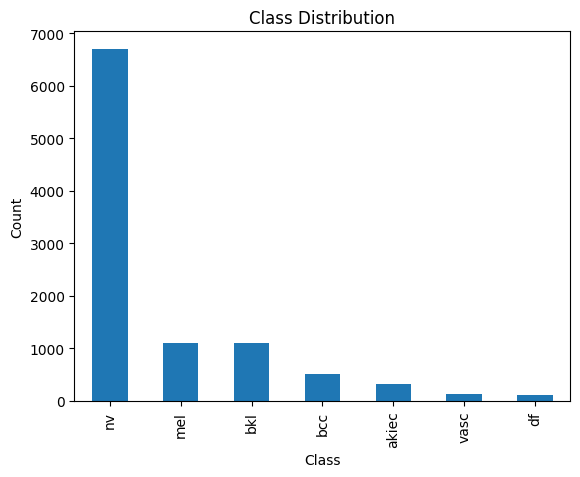

In [17]:
df['dx'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [18]:
from pathlib import Path

DATA_DIR = Path('../data')

def find_image(image_id):
    for part in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
        candidate = DATA_DIR / part / f'{image_id}.jpg'
        if candidate.exists():
            return candidate
    raise FileNotFoundError(image_id)

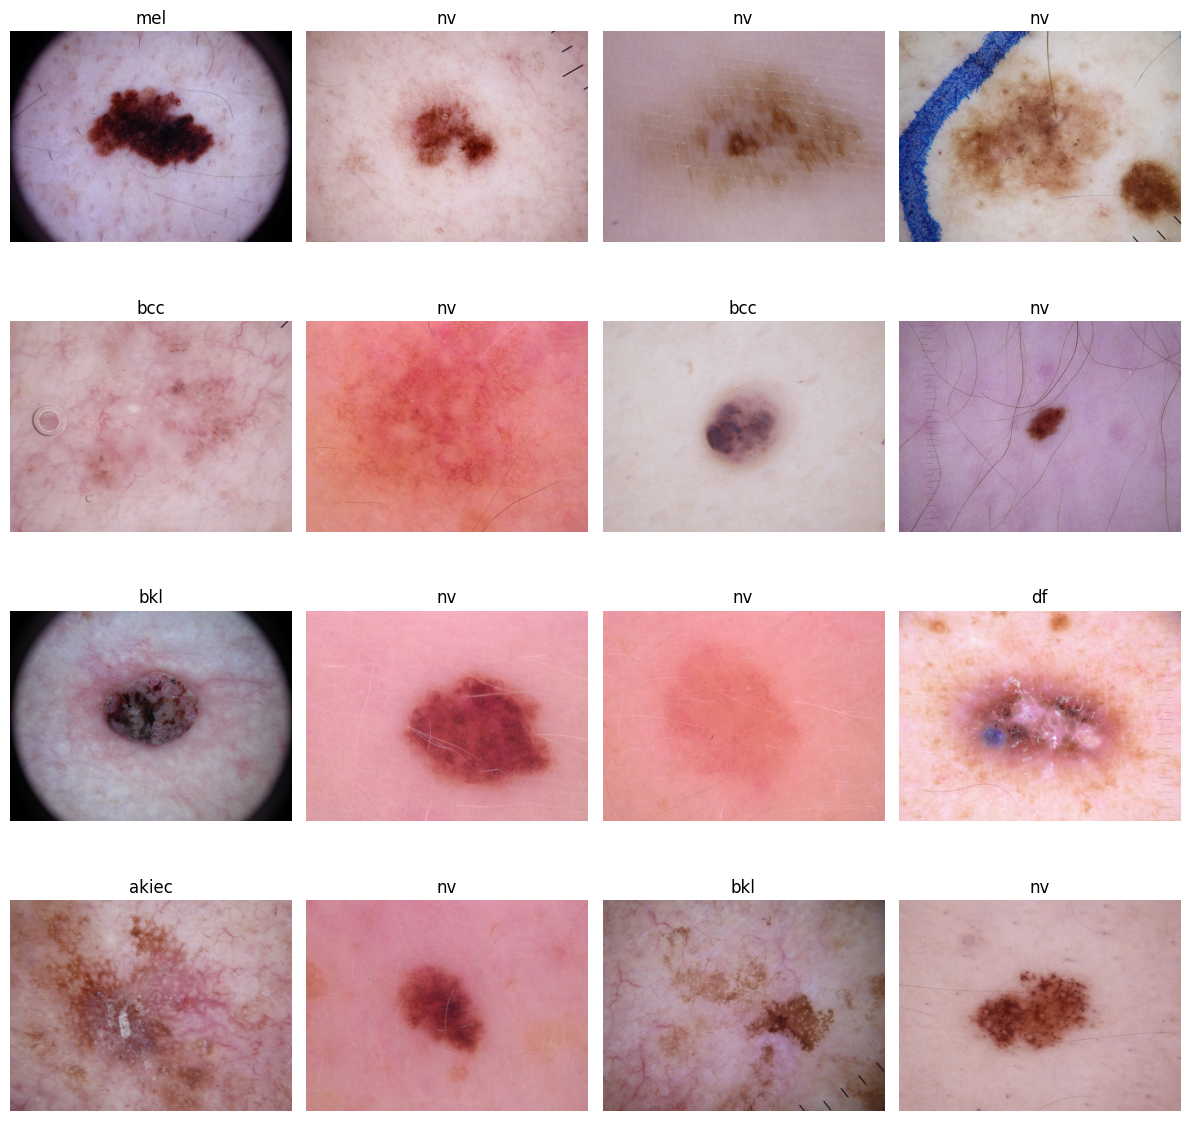

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, (_, row) in zip(axes.flatten(), df.sample(16).iterrows()):
    img = Image.open(find_image(row['image_id']))
    ax.imshow(img)
    ax.set_title(row['dx'])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [20]:
img = Image.open(find_image(df.iloc[0]['image_id']))
print(img.size, img.mode, img.format)

(600, 450) RGB JPEG


## Findings

- Dataset has 10,015 images across 7 classes, but only ~7,500 unique lesions
  (some lesions have multiple images — important for train/test splitting later).
- Severe class imbalance:
  - `nv` (benign moles) dominates at ~67% of the data
  - `df` (dermatofibroma) is only ~1%
  - Ratio of largest to smallest class is ~58:1
- All images appear to be RGB JPEGs at 600×450 resolution.

## Implications for modeling

- Accuracy is a misleading metric here — predicting all `nv` gives ~67%.
- Need to track per-class recall, especially for `mel` (melanoma — the
  clinically important class to catch).
- Likely interventions: class-weighted loss, oversampling minority classes,
  or focal loss.
- Train/test split must be by `lesion_id`, not `image_id`, to avoid leakage.

In [2]:
import sys
sys.path.insert(0, '..')

from src.ham10000.data import Ham10000Dataset
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = Ham10000Dataset(
    csv_path='../data/HAM10000_metadata.csv',
    image_dir='../data',
    transform=transform
)

print("Number of samples in dataset:", len(dataset))
print("Class Mapping:", dataset.class_to_idx)

for i in [0, 5000, 10000]:
    img, label = dataset[i]
    print(f"idx {i}: Image shape: {img.shape}, Label: {label}")

Number of samples in dataset: 10015
Class Mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
idx 0: Image shape: torch.Size([3, 224, 224]), Label: 2
idx 5000: Image shape: torch.Size([3, 224, 224]), Label: 5
idx 10000: Image shape: torch.Size([3, 224, 224]), Label: 0


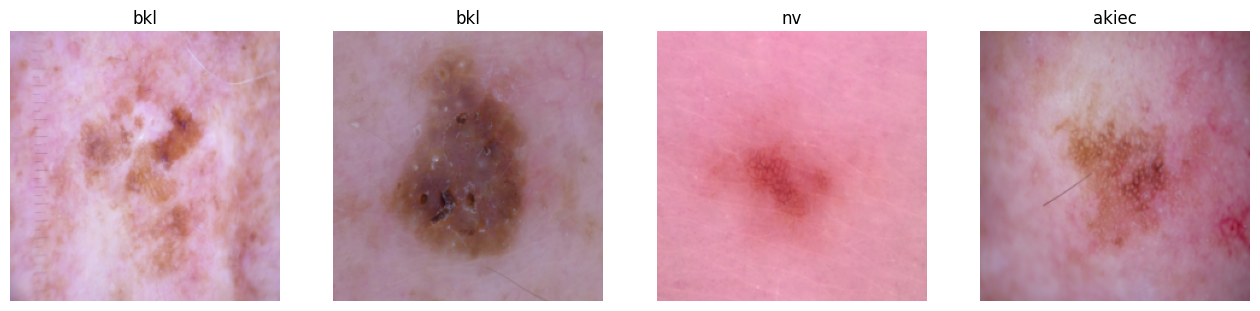

In [5]:
import matplotlib.pyplot as plt

idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i in zip(axes, [0, 100, 5000, 10000]):
    img, label = dataset[i]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(f"{idx_to_class[label]}")
    ax.axis('off')
plt.show()